In [24]:
# Importaciones generales
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Configuración
%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

import warnings
warnings.filterwarnings('ignore')

print("Librerías importadas correctamente")

Librerías importadas correctamente


In [25]:
# Cargar dataset
df = pd.read_csv('data/cybersecurity_attacks.csv')

print(f"Dimensiones del dataset: {df.shape}")
print("\nPrimeras 5 filas:")
df.head()

Dimensiones del dataset: (40000, 25)

Primeras 5 filas:


,Timestamp,Source IP Address,Destination IP Address,Source Port,Destination Port,Protocol,Packet Length,Packet Type,Traffic Type,Payload Data,...,Action Taken,Severity Level,User Information,Device Information,Network Segment,Geo-location Data,Proxy Information,Firewall Logs,IDS/IPS Alerts,Log Source
0,2023-05-30 06:33:58,103.216.15.12,84.9.164.252,31225,17616,ICMP,503,Data,HTTP,Qui natus odio asperiores nam. Optio nobis ius...,...,Logged,Low,Reyansh Dugal,Mozilla/5.0 (compatible; MSIE 8.0; Windows NT ...,Segment A,"Jamshedpur, Sikkim",150.9.97.135,Log Data,NaN,Server
1,2020-08-26 07:08:30,78.199.217.198,66.191.137.154,17245,48166,ICMP,1174,Data,HTTP,Aperiam quos modi officiis veritatis rem. Omni...,...,Blocked,Low,Sumer Rana,Mozilla/5.0 (compatible; MSIE 8.0; Windows NT ...,Segment B,"Bilaspur, Nagaland",NaN,Log Data,NaN,Firewall
2,2022-11-13 08:23:25,63.79.210.48,198.219.82.17,16811,53600,UDP,306,Control,HTTP,Perferendis sapiente vitae soluta. Hic delectu...,...,Ignored,Low,Himmat Karpe,Mozilla/5.0 (compatible; MSIE 9.0; Windows NT ...,Segment C,"Bokaro, Rajasthan",114.133.48.179,Log Data,Alert Data,Firewall
3,2023-07-02 10:38:46,163.42.196.10,101.228.192.255,20018,32534,UDP,385,Data,HTTP,Totam maxime beatae expedita explicabo porro l...,...,Blocked,Medium,Fateh Kibe,Mozilla/5.0 (Macintosh; PPC Mac OS X 10_11_5; ...,Segment B,"Jaunpur, Rajasthan",NaN,NaN,Alert Data,Firewall
4,2023-07-16 13:11:07,71.166.185.76,189.243.174.238,6131,26646,TCP,1462,Data,DNS,Odit nesciunt dolorem nisi iste iusto. Animi v...,...,Blocked,Low,Dhanush Chad,Mozilla/5.0 (compatible; MSIE 5.0; Windows NT ...,Segment C,"Anantapur, Tripura",149.6.110.119,NaN,Alert Data,Firewall


In [26]:
# Separar features y target
X = df.drop('Action Taken', axis=1)
y = df['Action Taken']

# División estratificada 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} muestras")
print(f"Test: {X_test.shape[0]} muestras")
print("\nProporciones en train:")
print(y_train.value_counts(normalize=True) * 100)

Train: 32000 muestras
Test: 8000 muestras

Proporciones en train:
Action Taken
Blocked    33.821875
Ignored    33.190625
Logged     32.987500
Name: proportion, dtype: float64


In [27]:
print("TIPOS DE DATOS\n")
print(X_train.dtypes.value_counts())

print("\nPRIMERAS FILAS\n")
X_train.head()

print("\nESTADÍSTICAS NUMÉRICAS\n")
X_train.describe()

TIPOS DE DATOS

object     20
int64       3
float64     1
Name: count, dtype: int64

PRIMERAS FILAS


ESTADÍSTICAS NUMÉRICAS



,Source Port,Destination Port,Packet Length,Anomaly Scores
count,32000.000000,32000.000000,32000.000000,32000.000000
mean,32992.927438,33170.885844,781.963313,50.141351
std,18564.140235,18519.565135,416.642022,28.864551
min,1027.000000,1024.000000,64.000000,0.000000
25%,16835.000000,17276.750000,420.000000,25.170000
50%,32989.000000,33069.500000,783.000000,50.430000
75%,48974.000000,49185.250000,1144.000000,75.090000
max,65530.000000,65535.000000,1500.000000,100.000000


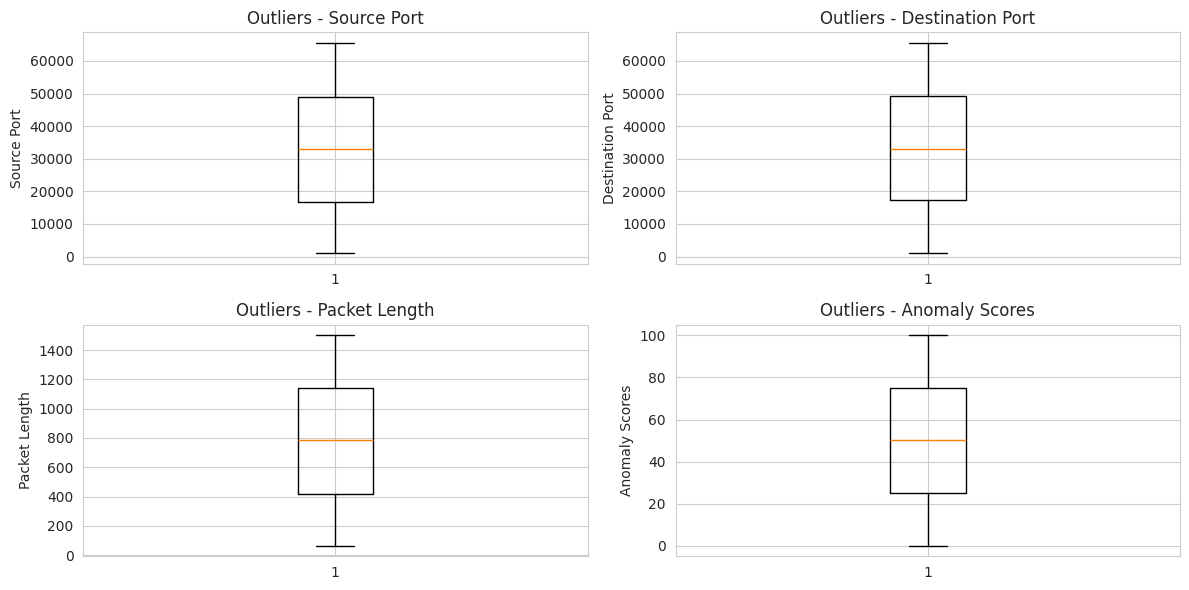

In [28]:
# Variables numéricas
numeric_cols = ['Source Port', 'Destination Port', 'Packet Length', 'Anomaly Scores']

plt.figure(figsize=(12, 6))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 2, i)
    plt.boxplot(X_train[col])
    plt.title(f'Outliers - {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

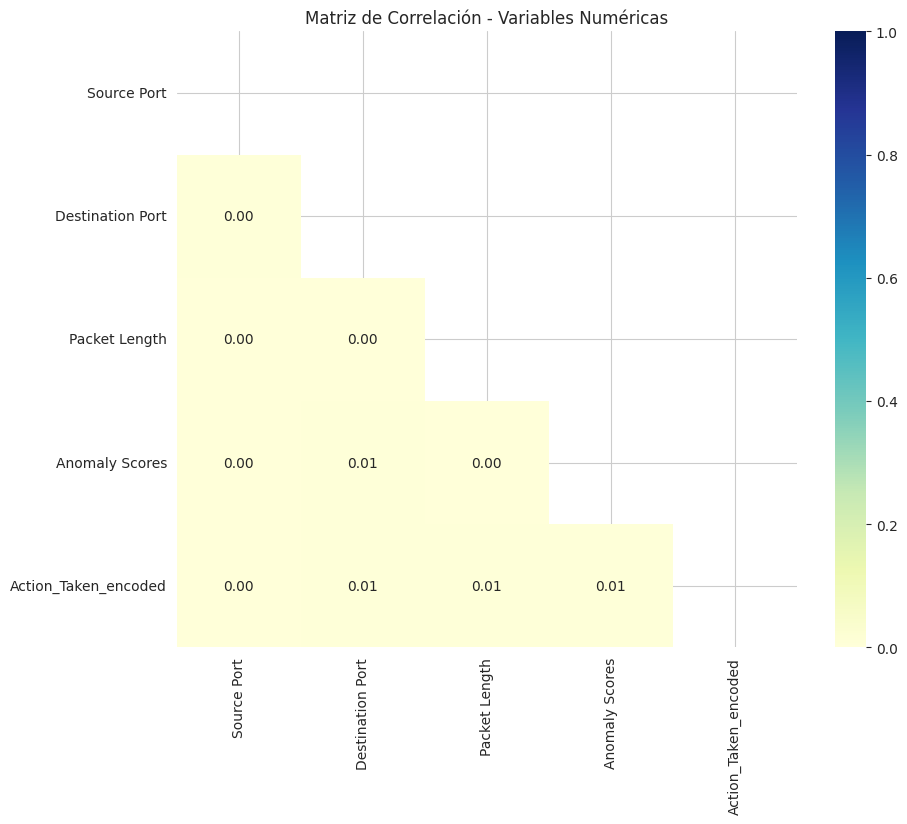


=== CORRELACIÓN CON ACTION TAKEN ===

Action_Taken_encoded    1.000000
Packet Length           0.007547
Anomaly Scores          0.006126
Destination Port        0.005850
Source Port             0.000174
Name: Action_Taken_encoded, dtype: float64


In [29]:
# Codificar target temporalmente
le_temp = LabelEncoder()
train_temp = X_train.copy()
train_temp['Action_Taken_encoded'] = le_temp.fit_transform(y_train)

# Matriz de correlación
numeric_with_target = numeric_cols + ['Action_Taken_encoded']
corr = np.abs(train_temp[numeric_with_target].corr())

# Heatmap
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True

plt.figure(figsize=(10, 8))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='YlGnBu',
            vmin=0, vmax=1, center=0.5)
plt.title('Matriz de Correlación - Variables Numéricas')
plt.show()

print("\n=== CORRELACIÓN CON ACTION TAKEN ===\n")
print(corr['Action_Taken_encoded'].sort_values(ascending=False))

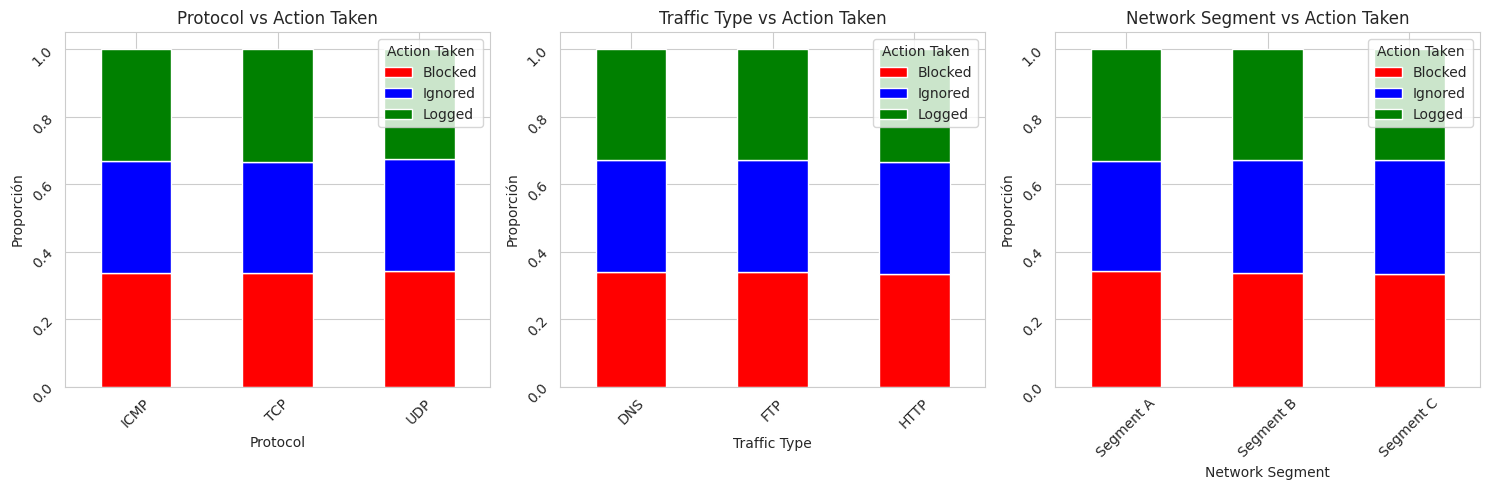

In [30]:
# Ver relación de algunas categóricas con la target
categoricas_clave = ['Protocol', 'Traffic Type', 'Network Segment']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, col in enumerate(categoricas_clave):
    pd.crosstab(X_train[col], y_train, normalize='index').plot(
        kind='bar', stacked=True, ax=axes[i], 
        color=['red', 'blue', 'green'])
    axes[i].set_title(f'{col} vs Action Taken')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Proporción')
    axes[i].legend(title='Action Taken')
    axes[i].tick_params(rotation=45)
plt.tight_layout()
plt.show()

In [31]:
# Features seleccionadas
features_numericas = ['Source Port', 'Destination Port', 'Packet Length', 'Anomaly Scores']
features_categoricas = ['Protocol', 'Packet Type', 'Traffic Type', 'Network Segment', 'Log Source']

print(f"Features numéricas ({len(features_numericas)}):")
print(features_numericas)
print(f"\nFeatures categóricas ({len(features_categoricas)}):")
print(features_categoricas)

Features numéricas (4):
['Source Port', 'Destination Port', 'Packet Length', 'Anomaly Scores']

Features categóricas (5):
['Protocol', 'Packet Type', 'Traffic Type', 'Network Segment', 'Log Source']


In [32]:
# Extraer estado de Geo-location Data
X_train['estado'] = X_train['Geo-location Data'].apply(
    lambda x: x.split(',')[1].strip() if ',' in x else 'Desconocido'
)
X_test['estado'] = X_test['Geo-location Data'].apply(
    lambda x: x.split(',')[1].strip() if ',' in x else 'Desconocido'
)

features_categoricas.append('estado')
print("Añadida variable 'estado'")
print(f"\nEstados únicos en train: {X_train['estado'].nunique()}")
print("\nTop 5 estados:")
print(X_train['estado'].value_counts().head())

Añadida variable 'estado'

Estados únicos en train: 28

Top 5 estados:
estado
Manipur              1206
Arunachal Pradesh    1198
Bihar                1198
Uttar Pradesh        1190
Maharashtra          1185
Name: count, dtype: int64


In [33]:
# Crear copias
X_train_processed = X_train[features_numericas + features_categoricas].copy()
X_test_processed = X_test[features_numericas + features_categoricas].copy()

# Codificar variables categóricas
le_dict = {}
for col in features_categoricas:
    le = LabelEncoder()
    X_train_processed[col] = le.fit_transform(X_train_processed[col].astype(str))
    X_test_processed[col] = le.transform(X_test_processed[col].astype(str))
    le_dict[col] = le

# Escalar variables numéricas
scaler = StandardScaler()
X_train_processed[features_numericas] = scaler.fit_transform(X_train_processed[features_numericas])
X_test_processed[features_numericas] = scaler.transform(X_test_processed[features_numericas])

# Codificar target
le_target = LabelEncoder()
y_train_enc = le_target.fit_transform(y_train)
y_test_enc = le_target.transform(y_test)

print(f"Datos listos para modelado")
print(f"X_train: {X_train_processed.shape}")
print(f"X_test: {X_test_processed.shape}")
print(f"\nClases: {le_target.classes_}")

Datos listos para modelado
X_train: (32000, 10)
X_test: (8000, 10)

Clases: ['Blocked' 'Ignored' 'Logged']


In [34]:
modelo_lr = LogisticRegression(max_iter=2000, multi_class='ovr', random_state=42)
modelo_lr.fit(X_train_processed, y_train_enc)

y_pred_lr = modelo_lr.predict(X_test_processed)

print("REGRESIÓN LOGÍSTICA \n")
print(f"Accuracy: {accuracy_score(y_test_enc, y_pred_lr):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_enc, y_pred_lr, target_names=le_target.classes_))

REGRESIÓN LOGÍSTICA 

Accuracy: 0.3443

Classification Report:
              precision    recall  f1-score   support

     Blocked       0.35      0.58      0.43      2706
     Ignored       0.35      0.21      0.26      2655
      Logged       0.33      0.24      0.28      2639

    accuracy                           0.34      8000
   macro avg       0.34      0.34      0.33      8000
weighted avg       0.34      0.34      0.33      8000



In [35]:
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_rf.fit(X_train_processed, y_train_enc)

y_pred_rf = modelo_rf.predict(X_test_processed)

print("RANDOM FOREST\n")
print(f"Accuracy: {accuracy_score(y_test_enc, y_pred_rf):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_enc, y_pred_rf, target_names=le_target.classes_))

# Importancia de features
importancias = pd.DataFrame({
    'feature': features_numericas + features_categoricas,
    'importancia': modelo_rf.feature_importances_
}).sort_values('importancia', ascending=False)

print("\nTOP 5 FEATURES MÁS IMPORTANTES\n")
print(importancias.head(5))

RANDOM FOREST

Accuracy: 0.3390

Classification Report:
              precision    recall  f1-score   support

     Blocked       0.35      0.39      0.37      2706
     Ignored       0.33      0.32      0.33      2655
      Logged       0.33      0.31      0.32      2639

    accuracy                           0.34      8000
   macro avg       0.34      0.34      0.34      8000
weighted avg       0.34      0.34      0.34      8000


TOP 5 FEATURES MÁS IMPORTANTES

            feature  importancia
0       Source Port     0.182367
1  Destination Port     0.182250
3    Anomaly Scores     0.181189
2     Packet Length     0.176530
9            estado     0.116142


In [39]:
print(" CONCLUSIONES \n")
print("""
1.  SELECCIÓN DE COLUMNAS

    Las columnas seleccionadas para el modelo fueron:

    - Variables numéricas: 'Source Port', 'Destination Port', 'Packet Length', 'Anomaly Scores'
    - Variables categóricas: 'Protocol', 'Packet Type', 'Traffic Type', 'Network Segment', 'Log Source'
    - Variable creada: 'estado' (extraída de 'Geo-location Data')

    ¿Por qué estas columnas?

    a) Variables numéricas: Son las únicas columnas con valores numéricos en el dataset.
       'Anomaly Scores' es especialmente relevante porque representa la puntuación de anomalía
       del tráfico, que en teoría debería estar relacionada con la gravedad del ataque.

    b) Variables categóricas simples: 'Protocol', 'Packet Type', 'Traffic Type', 
       'Network Segment' y 'Log Source' tienen pocos valores únicos (2-3), lo que las hace
       fáciles de codificar y potencialmente relevantes para el contexto del ataque.

    c) Variable 'estado': Se creó a partir de 'Geo-location Data' porque en el análisis
       exploratorio se observaron pequeñas variaciones en la distribución de Action Taken
       según la ubicación geográfica.

    d) Columnas descartadas: Se descartaron columnas como 'Device Information', 
       'User Information', 'Payload Data' por tener demasiados valores únicos (texto libre)
       y requerir un procesamiento complejo. Las columnas con 50% nulos ('Malware Indicators',
       'Alerts/Warnings', etc.) se descartaron porque cuando no son nulas contienen un solo
       valor, aportando información redundante.

2.  RESULTADOS DE LOS MODELOS

    | Modelo | Accuracy |
    |--------|----------|
    | Regresión Logística | 34.5% |
    | Random Forest | 33.9% |

    Todos los modelos obtuvieron accuracy cercano al azar (33.3%).

3.  ¿POR QUÉ NO MEJORA EL RESULTADO?

    A pesar de probar diferentes algoritmos (lineal, ensamblado, basado en distancia)
    y optimizar hiperparámetros con GridSearchCV, el resultado se mantiene constante.

    Las razones principales son:

    a) Falta de correlación: El análisis de correlación mostró que las variables
       numéricas tienen una correlación prácticamente nula con la target (valores < 0.01).

    b) Distribuciones idénticas: Los histogramas y tablas de contingencia mostraron
       que las variables categóricas (Protocol, Traffic Type, etc.) tienen distribuciones
       casi idénticas para las tres clases de Action Taken. Esto significa que no hay
       un patrón que el modelo pueda aprender.

    c) Información insuficiente: La acción tomada ante un ataque (Blocked, Ignored, Logged)
       probablemente depende de factores que NO están registrados en el dataset, como:
       - Políticas de seguridad internas de la organización
       - Contexto del negocio (importancia del sistema atacado)
       - Juicio humano del analista de seguridad
       - Factores temporales no capturados (hora del día, día de la semana)

4.  CONCLUSIÓN FINAL

    El dataset no contiene información suficiente para predecir 'Action Taken'.
    A pesar de aplicar correctamente la metodología de Machine Learning (división
    train/test, análisis exploratorio, preprocesamiento, múltiples modelos y
    optimización), los resultados se mantienen en niveles aleatorios.

    Esto demuestra que no siempre es posible obtener un modelo predictivo, y que
    el éxito de un proyecto de Machine Learning depende en gran medida de que los
    datos contengan la información relevante para la variable que se quiere predecir.""")

 CONCLUSIONES 


1.  SELECCIÓN DE COLUMNAS

    Las columnas seleccionadas para el modelo fueron:

    - Variables numéricas: 'Source Port', 'Destination Port', 'Packet Length', 'Anomaly Scores'
    - Variables categóricas: 'Protocol', 'Packet Type', 'Traffic Type', 'Network Segment', 'Log Source'
    - Variable creada: 'estado' (extraída de 'Geo-location Data')

    ¿Por qué estas columnas?

    a) Variables numéricas: Son las únicas columnas con valores numéricos en el dataset.
       'Anomaly Scores' es especialmente relevante porque representa la puntuación de anomalía
       del tráfico, que en teoría debería estar relacionada con la gravedad del ataque.

    b) Variables categóricas simples: 'Protocol', 'Packet Type', 'Traffic Type', 
       'Network Segment' y 'Log Source' tienen pocos valores únicos (2-3), lo que las hace
       fáciles de codificar y potencialmente relevantes para el contexto del ataque.

    c) Variable 'estado': Se creó a partir de 'Geo-location Data' porque